# Generation perplexity during training

List any number of run names below, then run all cells in Colab or a local Jupyter
notebook (CPU is sufficient). In Colab, Drive is mounted automatically. Locally,
set `BASE_DIR` to the folder containing your run directories, either downloaded
or synced with Google Drive for desktop. Each run uses `generation_metrics.jsonl` and `metrics.jsonl`.
No models or datasets are loaded.

Local dependencies: `pip install pandas numpy matplotlib ipykernel` in your notebook
kernel environment. Locally, the notebook uses the configured synced Drive folder
when available, otherwise this repository's `outputs` directory.

On the left axis, solid lines show **mean per-answer perplexity**, dotted lines
show **median perplexity**, and shading shows **25th–75th percentiles (IQR)**. Dashed lines show **validation weighted loss**
from `metrics.jsonl` on the right axis, starting at step 250 by default.
Each run uses the same color on both axes. Only `split="validation"` records
(or the spelling `"alidation"`) are used for loss; training/test records are excluded.
Validation loss is already an aggregate, so it is plotted directly without an IQR.
The two metrics keep their own evaluation steps; no interpolation or alignment is required.

The perplexity IQR describes the spread of answers, not a confidence interval for the mean.
It is different from token-pooled perplexity, which cannot be recovered from
per-answer perplexities alone without their scored token counts.
Compare runs scored with the same reference model/tokenizer and generation protocol.

In [43]:
from pathlib import Path

try:
    from google.colab import drive
except ModuleNotFoundError:
    # Jupyter may start in the repository root or in its notebooks directory.
    project_dir = Path.cwd()
    if project_dir.name == "notebooks":
        project_dir = project_dir.parent
    synced_outputs = Path(
        "/Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/"
        "My Drive/lad-generic-results/outputs"
    )
    DEFAULT_BASE_DIR = synced_outputs if synced_outputs.is_dir() else project_dir / "outputs"
    print(f"Running locally. Run folders: {DEFAULT_BASE_DIR}")
else:
    drive.mount("/content/drive")
    DEFAULT_BASE_DIR = Path("/content/drive/MyDrive/lad-generic-results/outputs")


Running locally. Run folders: /Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/My Drive/lad-generic-results/outputs


In [44]:
# Edit this list: one directory name per run, with as many runs as you like.
RUN_NAMES = [
    "llama-3.1-8b-mask-frontier-2",
    "llama-3.1-8b-mask-frontier-all-tokens",
    "llama-3.1-8b-mask-frontier-answer90-padding10",
]
BASE_DIR = DEFAULT_BASE_DIR
# Local override: the directory containing <run>/generation_metrics.jsonl.
# BASE_DIR = Path("~/Downloads/lad-generic-results/outputs").expanduser()
LOG_Y = False
MIN_VALIDATION_STEP = 250  # Include validation loss from this step onward.



In [45]:
import json
import numpy as np
import pandas as pd
from IPython.display import display


def read_records(path):
    if not path.is_file():
        print(f"File not found (skipping): {path}")
        return pd.DataFrame()
    records, malformed = [], 0
    with path.open() as stream:
        for line in stream:
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                malformed += 1  # A running job may not have finished its last line.
                continue
            if isinstance(record, dict):
                records.append(record)
            else:
                malformed += 1
    if malformed:
        print(f"{path}: skipped {malformed} malformed record(s).")
    frame = pd.DataFrame(records)
    if "step" not in frame:
        return pd.DataFrame()
    frame["step"] = pd.to_numeric(frame["step"], errors="coerce")
    return frame.loc[np.isfinite(frame["step"]) & (frame["step"] >= 0)].copy()


perplexity_summaries = {}
validation_losses = {}
for run_name in dict.fromkeys(RUN_NAMES):
    run_dir = BASE_DIR / run_name
    frame = read_records(run_dir / "generation_metrics.jsonl")
    if "generation_perplexity" in frame:
        if "prompt_index" in frame and frame["prompt_index"].notna().all():
            frame = frame.drop_duplicates(["step", "prompt_index"], keep="last")
        values = pd.to_numeric(frame["generation_perplexity"], errors="coerce")
        valid = np.isfinite(values) & (values > 0)
        if (~valid).any():
            print(f"{run_name}: excluded {int((~valid).sum())} invalid perplexity value(s).")
        frame = frame.loc[valid].copy()
        frame["generation_perplexity"] = values.loc[valid]
        if not frame.empty:
            perplexity_summaries[run_name] = frame.groupby("step", sort=True)["generation_perplexity"].agg(
                mean="mean", median="median", q25=lambda values: values.quantile(0.25),
                q75=lambda values: values.quantile(0.75), n="count",
            )

    # Load independently: loss can be available more often than generation metrics.
    frame = read_records(run_dir / "metrics.jsonl")
    if {"split", "weighted_loss"}.issubset(frame.columns):
        frame = frame.loc[frame["split"].isin(["validation", "alidation"])
                          & (frame["step"] >= MIN_VALIDATION_STEP)].copy()
        frame["weighted_loss"] = pd.to_numeric(frame["weighted_loss"], errors="coerce")
        # A resumed run may have logged the same validation step more than once.
        frame = frame.drop_duplicates("step", keep="last")
        valid = np.isfinite(frame["weighted_loss"]) & (frame["weighted_loss"] >= 0)
        if (~valid).any():
            print(f"{run_name}: excluded {int((~valid).sum())} invalid validation loss value(s).")
        frame = frame.loc[valid].sort_values("step")
        if not frame.empty:
            validation_losses[run_name] = frame.set_index("step")["weighted_loss"]
    print(f"{run_name}: {len(perplexity_summaries.get(run_name, []))} perplexity steps, "
          f"{len(validation_losses.get(run_name, []))} validation loss steps.")

if not perplexity_summaries and not validation_losses:
    raise ValueError("No valid runs found. Check RUN_NAMES, BASE_DIR and MIN_VALIDATION_STEP.")

if perplexity_summaries:
    stats = pd.concat(perplexity_summaries, names=["run", "step"])
    display(stats)
if validation_losses:
    loss_stats = pd.concat(validation_losses, names=["run", "step"]).rename("weighted_loss").to_frame()
    display(loss_stats)


llama-3.1-8b-mask-frontier-2: 27 perplexity steps, 111 validation loss steps.
llama-3.1-8b-mask-frontier-all-tokens: 17 perplexity steps, 67 validation loss steps.
/Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/My Drive/lad-generic-results/outputs/llama-3.1-8b-mask-frontier-answer90-padding10/metrics.jsonl: skipped 1 malformed record(s).
llama-3.1-8b-mask-frontier-answer90-padding10: 18 perplexity steps, 74 validation loss steps.


mean    median  \
run                                           step                         
llama-3.1-8b-mask-frontier-2                  1000   11.139578  9.892512   
                                              2000   19.800866  9.451837   
                                              3000    9.363184  8.618102   
                                              4000   14.915300  9.506972   
                                              5000    8.765462  8.395941   
...                                                        ...       ...   
llama-3.1-8b-mask-frontier-answer90-padding10 14000   8.705227  7.655869   
                                              15000   7.813712  7.511463   
                                              16000   8.722570  7.765374   
                                              17000   8.375391  8.512307   
                                              18000   8.611980  8.306049   

                                                          q25        q75   n  
run                                           step                            
llama-3.1-8b-mask-frontier-2                  1000   8.256030  13.936134  30  
                                              2000   8.180148  17.319467  30  
                                              3000   6.688729  11.172510  30  
                                              4000   7.247583  12.392735  30  
                                              5000   6.309812  11.245270  30  
...                                                       ...        ...  ..  
llama-3.1-8b-mask-frontier-answer90-padding10 14000  6.160318  10.236082  30  
                                              15000  5.745273   8.619084  30  
                                              16000  5.676896   9.628085  30  
                                              17000  6.903464  10.249615  30  
                                              18000  6.524140   9.734778  30  

[62 rows x 5 columns]

weighted_loss
run                                           step                
llama-3.1-8b-mask-frontier-2                  250         1.063721
                                              500         0.958711
                                              750         0.901647
                                              1000        0.877517
                                              1250        0.860945
...                                                            ...
llama-3.1-8b-mask-frontier-answer90-padding10 17500       1.182275
                                              17750       1.193297
                                              18000       1.198228
                                              18250       1.195718
                                              18500       1.195935

[252 rows x 1 columns]

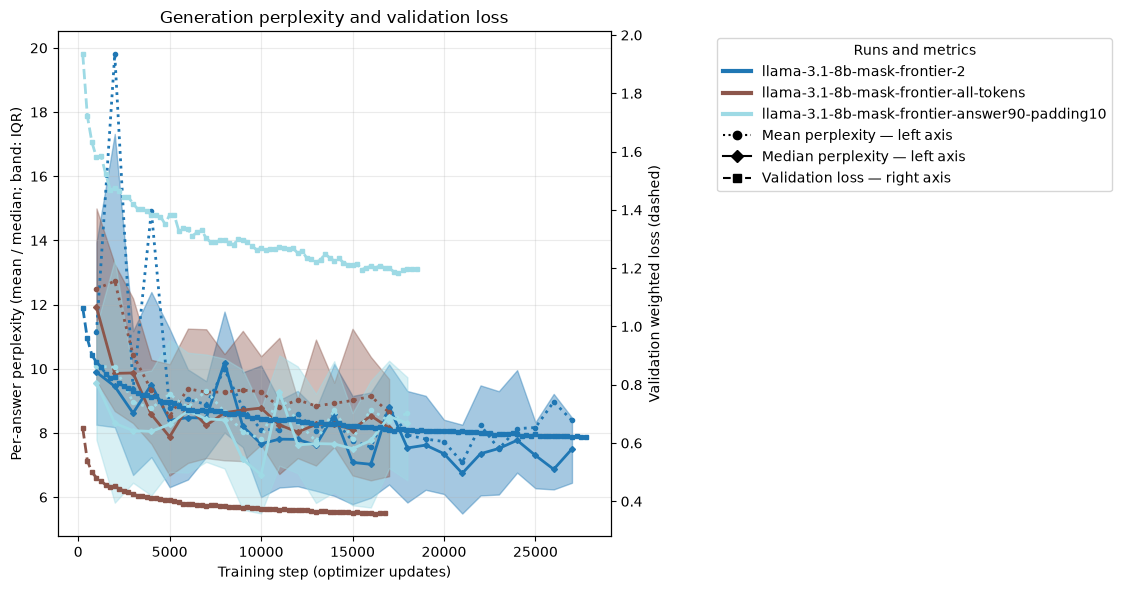

In [46]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 6))
loss_ax = ax.twinx()
plotted_runs = [name for name in dict.fromkeys(RUN_NAMES)
                if name in perplexity_summaries or name in validation_losses]
colors = plt.get_cmap("tab20" if len(plotted_runs) <= 20 else "turbo")
legend_handles = []
for index, run_name in enumerate(plotted_runs):
    color = colors(index / max(len(plotted_runs) - 1, 1))
    legend_handles.append(Line2D([], [], color=color, linewidth=3, label=run_name))
    summary = perplexity_summaries.get(run_name)
    if summary is not None:
        steps = summary.index.to_numpy(dtype=float)
        ax.plot(steps, summary["mean"].to_numpy(), color=color,
                linewidth=2, linestyle=":", marker="o", markersize=3)
        ax.plot(steps, summary["median"].to_numpy(), color=color,
                linewidth=2, linestyle="-", marker="D", markersize=3)
        ax.fill_between(steps, summary["q25"].to_numpy(), summary["q75"].to_numpy(),
                        color=color, alpha=0.4)
    loss = validation_losses.get(run_name)
    if loss is not None:
        loss_ax.plot(loss.index.to_numpy(dtype=float), loss.to_numpy(), color=color,
                     linewidth=2, linestyle="--", marker="s", markersize=3)

LOG_VALIDATION_LOSS = False  # Set True if early, very large perplexities obscure later steps.

if LOG_Y:
    ax.set_yscale("log")
if LOG_VALIDATION_LOSS:
    loss_ax.set_yscale("log", nonpositive="mask")  # Zero loss has no finite log value.
ax.set(title="Generation perplexity and validation loss",
       xlabel="Training step (optimizer updates)", ylabel="Per-answer perplexity (mean / median; band: IQR)")
loss_ax.set_ylabel("Validation weighted loss (dashed)")
ax.grid(True, alpha=0.25)
legend_handles.extend([
    Line2D([], [], color="black", linestyle=":", marker="o", label="Mean perplexity — left axis"),
    Line2D([], [], color="black", linestyle="-", marker="D", label="Median perplexity — left axis"),
    Line2D([], [], color="black", linestyle="--", marker="s", label="Validation loss — right axis"),
])
ax.legend(handles=legend_handles, title="Runs and metrics",
          bbox_to_anchor=(1.18, 1), loc="upper left")
fig.tight_layout()
plt.show()

# Optional: save the displayed figure to Drive.
# fig.savefig(BASE_DIR.parent / "generation-perplexity-comparison.png", dpi=200, bbox_inches="tight")
